In [16]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss


from copy import deepcopy

## Generación de datos

In [17]:
# Diagonales

def diagonales(n, d, C):
  mean0 = np.full(d,-1)
  mean1 = np.full(d,1)
    
  desviacion_std = C * np.sqrt(d)
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Paralelas

def paralelas(n, d, C):
  mean0 = np.zeros(d)
  mean1 = np.zeros(d)
  mean0[0] = 1
  mean1[0] = -1

  desviacion_std = C
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Espirales

def toCartesianP(r, theta):
  x = r * np.cos(theta)
  y = r * np.sin(theta)
  return (x, y)

def toCartesianA(rs, thetas):
  a = [(r * np.cos(theta), r * np.sin(theta)) for r, theta in zip(rs, thetas)]
  return a

def espirales(n):
  r0s = np.sqrt(np.random.uniform(0, 1, n//2))  
  a0s = np.random.uniform(0, 1, n//2)
  theta0s = [np.pi*(4*r-a) for r,a in zip(r0s,a0s)]

  r1s = np.sqrt(np.random.uniform(0, 1, n//2))
  a1s = np.random.uniform(-1, 0, n//2)
  theta1s = [np.pi*(4*r-a) for r,a in zip(r1s,a1s)]

  input0 = toCartesianA(r0s,theta0s)
  input1 = toCartesianA(r1s,theta1s)

  output0 = np.full(n//2, 0)
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0,output1]).tolist()

## Definimos nuestras redes

In [ ]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas=10   # numero de epocas que entrena cada vez
super_epocas=100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta=0.01        # learning rate
alfa=0.9        # momentum
N2=4            # neuronas en la capa oculta

In [ ]:
# Defino MLP para regresión
def Regressor():
    return MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa,nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)   

print(Regressor())

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(4,), learning_rate_init=0.01, max_iter=10,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [20]:
# Defino MLP para clasificación
def Classifier():
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(Classifier())

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(2,), learning_rate_init=0.1, max_iter=1000,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Funcion de entrenamiento

In [18]:
def entrenar_red(red,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "super_epocas" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red

    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

## Ejercicio 1

In [33]:
eta = 0.1
alfa = 0.9
N2s = [2, 10, 20, 40]
sub_epocas = 1000
super_epocas = 20

X_test, Y_test = espirales(2000)

df = {
    2: {},
    10: {},
    20: {},
    40: {}
}

for N2 in N2s:
    cla = Classifier()
    train = espirales(600)
    X_train,X_val,Y_train,Y_val = skl.model_selection.train_test_split(train[0], train[1])
    best_fit = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    Y_ans = best_fit[0].predict(X_test)
    df[N2] = {"input": X_test, "output": Y_ans}

df = pd.DataFrame.from_dict(df)

display(df)

,2,10,20,40
input,"[[0.07094630062528211, -0.09409357191803304], ...","[[0.07094630062528211, -0.09409357191803304], ...","[[0.07094630062528211, -0.09409357191803304], ...","[[0.07094630062528211, -0.09409357191803304], ..."
output,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."


Ahora graficamos las predicciones

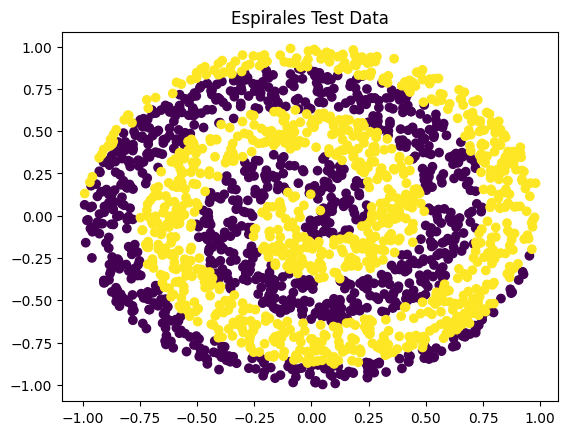

In [ ]:
def plotEspiral(dd):
    N2s = df.keys()
    fig, axs = plt.subplots(1, len(N2s), figsize=(20, 5))
    for N2, ax in zip(N2s, axs):
        X = df[N2]["input"]
        Y = df[N2]["output"]
        ax.scatter([x[0] for x in X], [x[1] for x in X], c=Y, label=f"N2={N2}")
        ax.set_title("Espirales {}".format(N2))
        ax.legend()
    plt.tight_layout()
    plt.show()

plotEspiral(df)

plt.scatter([x[0] for x in X_test], [x[1] for x in X_test], c=Y_test, label='Test Data')
plt.title("Espirales Test Data")
plt.show()